# NYC Construction Permit Approval Duration
## Regularization Models

This notebook applies Ridge, Lasso, and Elastic Net regularization to the 
baseline linear regression framework. The goal is to assess whether penalized 
regression improves predictive performance and to use Lasso's sparsity property 
for feature selection.

In [2]:
import pandas as pd
import numpy as np
from sklearn.linear_model import RidgeCV, LassoCV, ElasticNetCV
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

df = pd.read_csv('permit_model_data.csv')

X = df.drop(columns=['approval_duration'])
y = df['approval_duration']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#### Ridge Regression

Ridge regression penalizes large coefficients without eliminating predictors. 
Cross-validation is used to select the optimal regularization strength (alpha).

In [3]:
ridge = RidgeCV(cv=5)
ridge.fit(X_train, y_train)

y_pred_ridge = ridge.predict(X_test)
rmse_ridge = np.sqrt(mean_squared_error(y_test, y_pred_ridge))
r2_ridge = r2_score(y_test, y_pred_ridge)

print(f"Ridge — Alpha: {ridge.alpha_:.4f} | RMSE: {rmse_ridge:.2f} | R²: {r2_ridge:.4f}")

Ridge — Alpha: 10.0000 | RMSE: 51.94 | R²: 0.0060


#### Lasso Regression

Lasso regression applies an L1 penalty that shrinks some coefficients to exactly 
zero, performing implicit feature selection. Cross-validation is used to select 
the optimal alpha.

In [4]:
lasso = LassoCV(cv=5, random_state=42)
lasso.fit(X_train, y_train)

y_pred_lasso = lasso.predict(X_test)
rmse_lasso = np.sqrt(mean_squared_error(y_test, y_pred_lasso))
r2_lasso = r2_score(y_test, y_pred_lasso)

print(f"Lasso — Alpha: {lasso.alpha_:.4f} | RMSE: {rmse_lasso:.2f} | R²: {r2_lasso:.4f}")
print(f"Non-zero coefficients: {(lasso.coef_ != 0).sum()} of {X.shape[1]}")

Lasso — Alpha: 0.1283 | RMSE: 51.90 | R²: 0.0075
Non-zero coefficients: 12 of 30


#### Elastic Net

Elastic Net combines L1 and L2 penalties, balancing feature selection and 
coefficient shrinkage. Cross-validation is used to select the optimal alpha 
and L1 ratio.

In [5]:
enet = ElasticNetCV(cv=5, random_state=42)
enet.fit(X_train, y_train)

y_pred_enet = enet.predict(X_test)
rmse_enet = np.sqrt(mean_squared_error(y_test, y_pred_enet))
r2_enet = r2_score(y_test, y_pred_enet)

print(f"Elastic Net — Alpha: {enet.alpha_:.4f} | L1 Ratio: {enet.l1_ratio_:.2f} | RMSE: {rmse_enet:.2f} | R²: {r2_enet:.4f}")
print(f"Non-zero coefficients: {(enet.coef_ != 0).sum()} of {X.shape[1]}")

Elastic Net — Alpha: 0.0636 | L1 Ratio: 0.50 | RMSE: 51.90 | R²: 0.0073
Non-zero coefficients: 22 of 30


#### Model Comparison

Summarize performance across all regularization methods alongside the baseline.

In [6]:
results = pd.DataFrame({
    'Model': ['Baseline OLS', 'Ridge', 'Lasso', 'Elastic Net'],
    'RMSE': [51.95, rmse_ridge, rmse_lasso, rmse_enet],
    'R²': [0.0054, r2_ridge, r2_lasso, r2_enet],
    'Non-zero Predictors': [30, 30, 12, 22]
})

print(results.to_string(index=False))

       Model      RMSE       R²  Non-zero Predictors
Baseline OLS 51.950000 0.005400                   30
       Ridge 51.940272 0.005974                   30
       Lasso 51.901027 0.007475                   12
 Elastic Net 51.904366 0.007348                   22


#### Model Comparison Plot

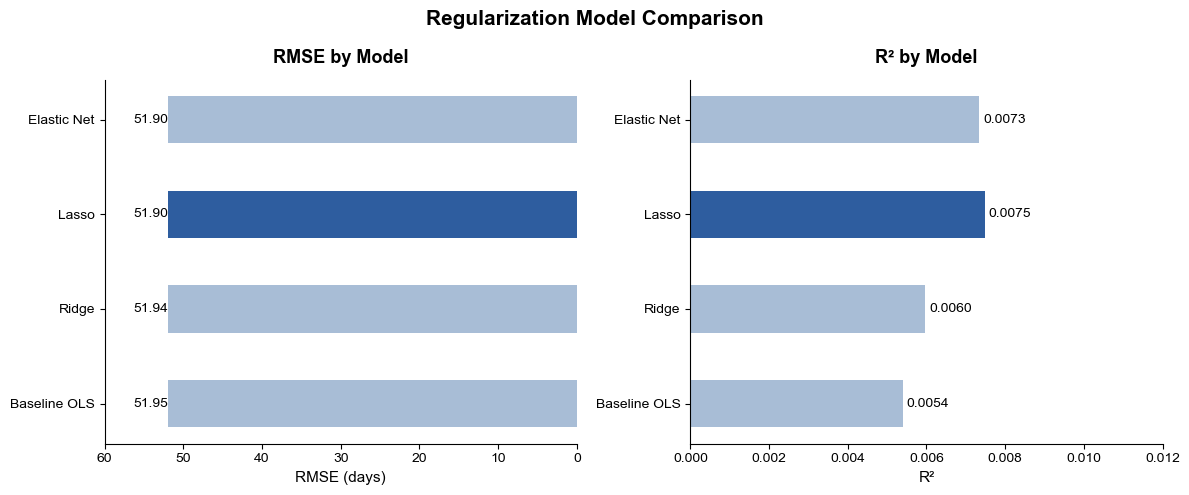

In [21]:
import matplotlib.pyplot as plt
import matplotlib as mpl

mpl.rcParams['font.family'] = 'Arial'
mpl.rcParams['axes.spines.top'] = False
mpl.rcParams['axes.spines.right'] = False

models = ['Baseline OLS', 'Ridge', 'Lasso', 'Elastic Net']
rmse_values = [51.95, rmse_ridge, rmse_lasso, rmse_enet]
r2_values = [0.0054, r2_ridge, r2_lasso, r2_enet]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Regularization Model Comparison', fontsize=15, fontweight='bold')

# RMSE chart
rmse_colors = ['#2E5D9F' if v == min(rmse_values) else '#A8BDD6' for v in rmse_values]
axes[0].barh(models, rmse_values, color=rmse_colors, height=0.5)
axes[0].set_xlabel('RMSE (days)', fontsize=11)
axes[0].set_title('RMSE by Model', fontsize=13, fontweight='bold', pad=12)
axes[0].set_xlim(0, 60)
axes[0].invert_xaxis()
for i, v in enumerate(rmse_values):
    axes[0].text(v - 0.005, i, f'{v:.2f}', va='center', fontsize=10, ha='right')

# R² chart
r2_colors = ['#2E5D9F' if v == max(r2_values) else '#A8BDD6' for v in r2_values]
axes[1].barh(models, r2_values, color=r2_colors, height=0.5)
axes[1].set_xlabel('R²', fontsize=11)
axes[1].set_title('R² by Model', fontsize=13, fontweight='bold', pad=12)
axes[1].set_xlim(0, 0.012)
for i, v in enumerate(r2_values):
    axes[1].text(v + 0.0001, i, f'{v:.4f}', va='center', fontsize=10)

plt.tight_layout()
plt.savefig('regularization_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

#### Results and Interpretation

All three regularization methods yield performance nearly identical to the baseline, 
with RMSE ranging from 51.90 to 51.95 and R² below 0.008 across all models. This 
consistency confirms that the low predictive performance is attributable to the 
features themselves rather than overfitting or coefficient instability.

Lasso's reduction to 12 non-zero predictors without any loss in performance suggests 
that the majority of categorical predictors carry redundant or negligible signal. 
The predictors that survive Lasso selection — primarily work type and permit type 
categories — are consistent with the coefficient analysis in Notebook 3.

#### Summary

Regularization does not meaningfully improve on the baseline linear regression. 
The categorical features available in this dataset explain very little variance 
in permit approval duration, a finding that is consistent across all penalized 
regression methods. Tree-based models are explored in Notebook 5 to assess 
whether non-linear relationships between predictors can improve performance.